In [98]:
""" Fitting squeezing model to data to recover r and phi

Import 2D char fn, assume Im part is 0
Normalise and baseline correct 2D char fn
Optional: Apply 2D FFT conversion to recover 2D wigner function.
    - check defn used by GC and SS/OB
Fit squeezing model to 2D wigner function
"""

from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
import graph_style as gs
import fig_helper as fh
gs.set_graph_style(1)

# fit 2D squeezing model to 2D char fn data
#X(Beta)=<D(Beta)>
def squeezing_model(xy, r, phi):
    """ From Sebastian thesis eqn 2.54"""
    x, y = xy
    absB = np.sqrt(x**2 + y**2)
    argB = np.arctan2(y, x)
    X = np.exp(-0.5 * absB**2 * (np.exp(2*r) * np.cos(argB - phi/2)**2 + np.exp(-2*r) * np.sin(argB - phi/2)**2))
    return X

def get_char(rid, day, Zvalue=False, flip_p =False):
    f = fh.load_data(rid=rid, day=day)

    if flip_p:
        z = 1-np.array(f['datasets'][f'ndscan.rid_{rid}.points.channel_measurement_camera_readout_p'])
    else:
        z = np.array(f['datasets'][f'ndscan.rid_{rid}.points.channel_measurement_camera_readout_p'])
    z_err = np.array(f['datasets'][f'ndscan.rid_{rid}.points.channel_measurement_camera_readout_p_err'])

    x = np.array(f['datasets'][f'ndscan.rid_{rid}.points.axis_0'])
    y = np.array(f['datasets'][f'ndscan.rid_{rid}.points.axis_1'])

    # Gets x, y axis and obtains a 2d bright_frac array
    X = list(np.unique(x))
    Y = list(np.unique(y))

    x = np.reshape(x, (len(X), len(Y)))
    y = np.reshape(y, (len(X), len(Y)))
    z = np.reshape(z, (len(X), len(Y)))
    z_err = np.reshape(z_err, (len(X), len(Y)))
    
    s = np.argsort(x[0,:])
    t= np.argsort(y[:,0])

    z = z[...,s]
    z = z[t,...]
             
    z_err = z_err[...,s]
    z_err = z_err[t,...]

    if Zvalue:
        z = 2*z -1
        z_err = 2*z_err

    return np.array(X), np.array(Y), z, z_err


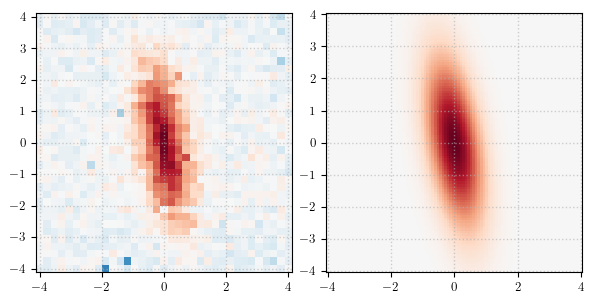

In [99]:
day = "2026-08-18"
rid = 138068

x,y,z,z_err = get_char(rid, day, Zvalue=True)

x_g, y_g = np.meshgrid(x, y)

popt, pcov = curve_fit(squeezing_model, (x_g.flatten(), y_g.flatten()), z.flatten(), p0=[0.5, 0.5], sigma=z_err.flatten())
r = popt[0]
phi = popt[1]

x_fit = np.linspace(np.min(x), np.max(x), 100)
y_fit = np.linspace(np.min(y), np.max(y), 100)
x_fit, y_fit = np.meshgrid(x_fit, y_fit)
z_fit = squeezing_model((x_fit, y_fit), r, phi)



fig_width = gs.get_fig_width()
fig_height = fig_width / 2
fig, ax = plt.subplots(1, 2, figsize=(fig_width, fig_height), constrained_layout=True)
ax[0].pcolormesh(x, y, z, shading='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax[1].pcolormesh(x_fit, y_fit, z_fit, shading='auto', cmap='RdBu_r', vmin=-1, vmax=1)


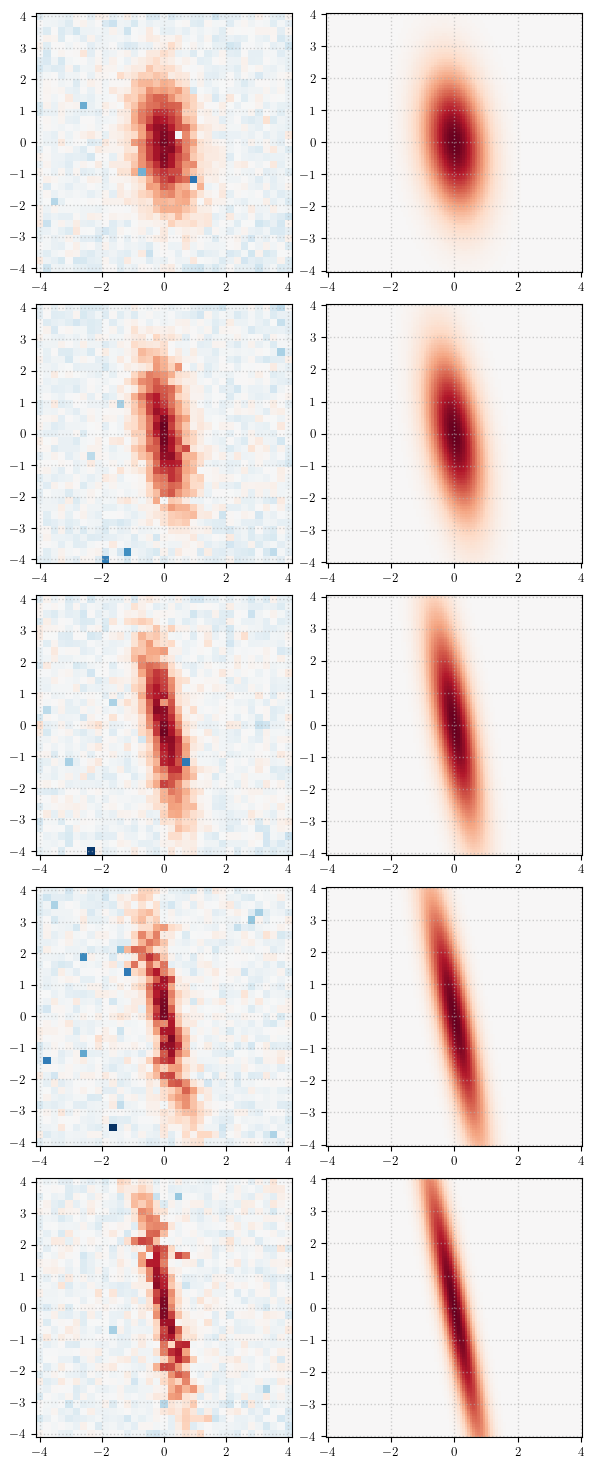

In [100]:

dates = ["2026-08-18", "2026-08-17"]
rids = [138069, 138068, 138067, 138066, 138065]#, 138064]
taus = [50, 100, 150, 200, 250]#, 250]

r_arr = []
r_err_arr = []
phi_arr = []
phi_err_arr = []
z_exp_arr = []
z_fit_arr = []

x_range = np.linspace(np.min(x), np.max(x), 100)
y_range = np.linspace(np.min(y), np.max(y), 100)
x_fit, y_fit = np.meshgrid(x_range, y_range)
for rid, tau in zip(rids, taus):
    for day in dates:
        try:
            x,y,z,z_err = get_char(rid, day, Zvalue=True)
        except Exception as e:
            pass
    z_exp_arr.append(z)

    x_g, y_g = np.meshgrid(x, y)

    popt, pcov = curve_fit(squeezing_model, (x_g.flatten(), y_g.flatten()), z.flatten(), p0=[0.5, 0.5], sigma=z_err.flatten())
    r = popt[0]
    phi = popt[1]
    r_arr.append(r)
    r_err_arr.append(np.sqrt(pcov[0,0]))
    phi_arr.append(phi)
    phi_err_arr.append(np.sqrt(pcov[1,1]))
    z_fit = squeezing_model((x_fit, y_fit), r, phi)
    z_fit_arr.append(z_fit)

num_rids = len(rids)
fig_width = gs.get_fig_width()
fig_height = fig_width * num_rids / 2
fig, ax = plt.subplots(num_rids, 2, figsize=(fig_width, fig_height), constrained_layout=True)
for i, (z_exp, z_fit) in enumerate(zip(z_exp_arr, z_fit_arr)):
    ax[i, 0].pcolormesh(x, y, z_exp, shading='auto', cmap='RdBu_r', vmin=-1, vmax=1)
    ax[i, 1].pcolormesh(x_fit, y_fit, z_fit, shading='auto', cmap='RdBu_r', vmin=-1, vmax=1)

Text(0, 0.5, 'r')

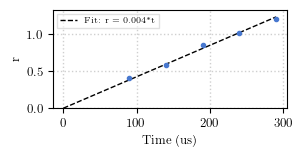

In [102]:
def linear_fit(x, m):
    return m*x 

t_ramp = 40
t_corrected = np.array(taus) + t_ramp
popt_r, pcov_r = curve_fit(linear_fit, t_corrected, r_arr)
popt_phi, pcov_phi = curve_fit(linear_fit, t_corrected, phi_arr)
x_fit_r = np.linspace(0, np.max(t_corrected), 100)
y_fit_r = linear_fit(x_fit_r, *popt_r)
x_fit_phi = np.linspace(0, np.max(t_corrected), 100)
y_fit_phi = linear_fit(x_fit_phi, *popt_phi)


fig_width = gs.get_fig_width()/2
fig_height = fig_width / 2
fig, ax = plt.subplots(1,1, figsize=(fig_width, fig_height), constrained_layout=True)
ax.errorbar(t_corrected, r_arr, yerr=r_err_arr, fmt='o')
ax.plot(x_fit_r, y_fit_r, color="black", label=f'Fit: r = {popt_r[0]:.3f}*t')
ax.set_ylim(0, max(r_arr)*1.1)
ax.legend()
ax.set_xlabel("Time (us)")
ax.set_ylabel("r")

